In [1]:
import os

import numpy as np
import pandas as pd
import xarray as xr
import dask
import glob

import multiprocessing
import matplotlib.pyplot as plt
import matplotlib as mpl

rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

plt.rcParams.update({'font.size': 18, 'axes.labelsize': 22})
from lmfit import models, report_fit
import PyMieScatt as ps

from mie_perso import psd, mie_multiprocess

opj = os.path.join

In [ ]:
import os

import numpy as np
import pandas as pd
import xarray as xr
import glob
from scipy.integrate import trapz  # import a single function for integration using trapezoidal rule
import multiprocessing
import matplotlib.pyplot as plt
import matplotlib as mpl

rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

plt.rcParams.update({'font.size': 18, 'axes.labelsize': 22})
from lmfit import models, report_fit
import PyMieScatt as ps

from mie_perso import psd, mie_multiprocess

In [ ]:
p = mie_multiprocess.processor()
size_param = psd.size_param
psd = psd.psd()

In [26]:
# set refractive index
m = 1.17 - 0.001j

# set size parameter
x=[1]

# set scattering angles
theta = np.linspace(0, np.pi, 3600)

# proceed with computation
scat_mat = p.ScatMat_mp(m, x, theta)
scat_mat

<xarray.Dataset>
Dimensions:  (x: 1, theta: 3600)
Coordinates:
  * x        (x) int64 1
  * theta    (theta) float64 0.0 0.0008729 0.001746 ... 3.14 3.141 3.142
    nr       float64 1.17
    ni       float64 -0.001
Data variables:
    S11      (x, theta) float64 0.01356 0.01356 0.01356 ... 0.005652 0.005652
    S12      (x, theta) float64 0.0 -5.007e-09 -2.003e-08 ... -2.239e-09 0.0
    S33      (x, theta) float64 0.01356 0.01356 0.01356 ... -0.005652 -0.005652
    S34      (x, theta) float64 0.0 -5.247e-12 -2.099e-11 ... -4.574e-12 0.0
Attributes:
    description:  non-null scattering matrix terms from Mie computations usin...

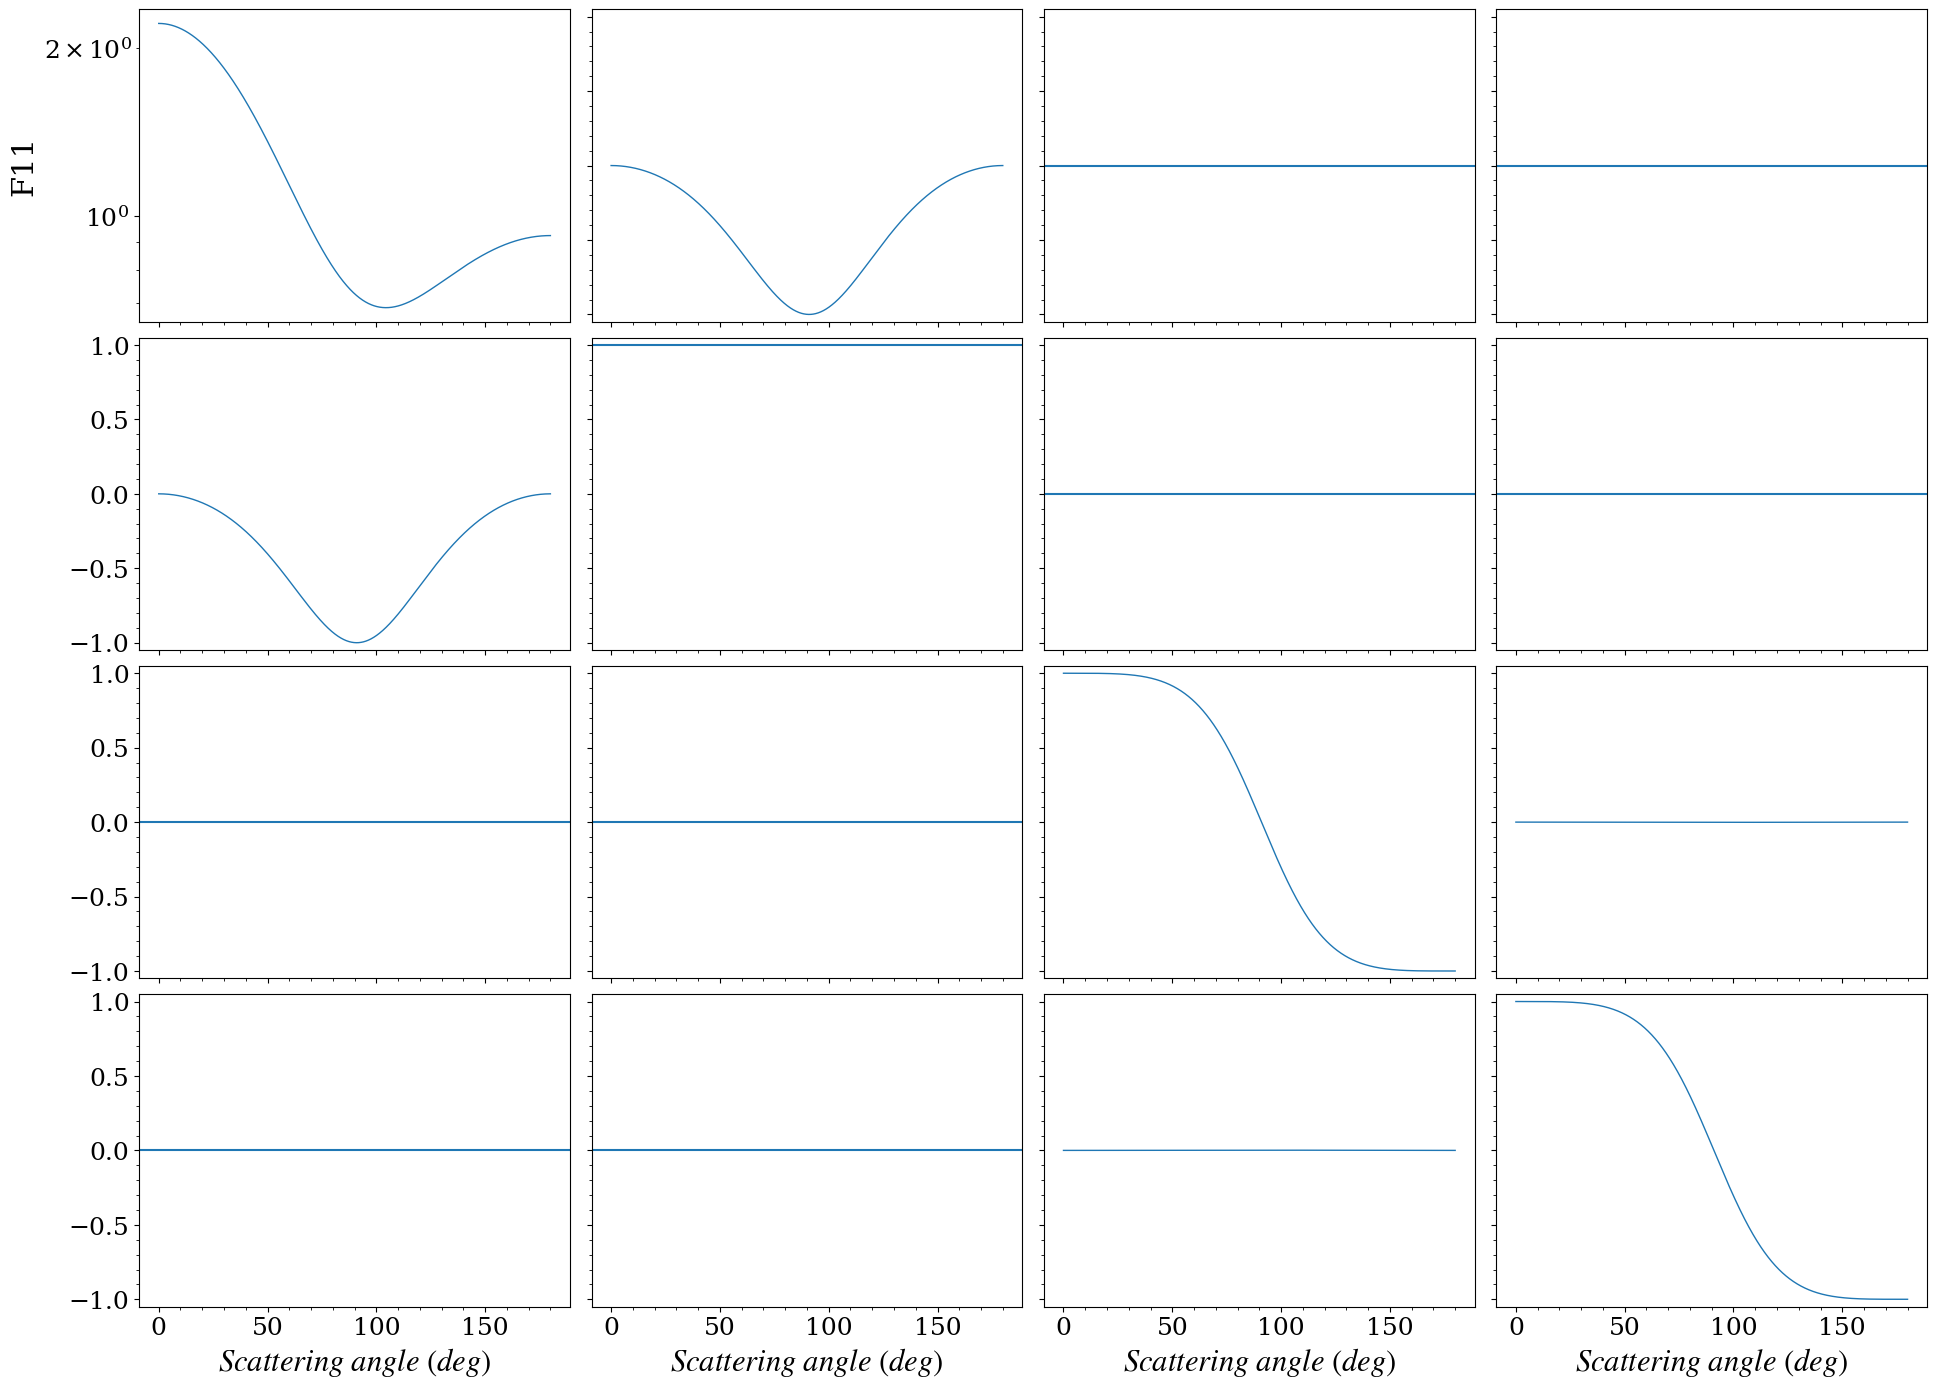

In [27]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 15), sharex=True)#, sharey='row')
fig.subplots_adjust(bottom=0.115, top=0.98, left=0.086, right=0.98,
                    hspace=0.05, wspace=0.05)
ang=np.degrees(theta)
S11 = scat_mat.S11.squeeze()
S12 = scat_mat.S12.squeeze()
S33 = scat_mat.S33.squeeze()
S34 = scat_mat.S34.squeeze()


norm = trapz(S11 * np.sin(theta), theta) / 2
axs[0, 0].plot(ang, S11 / norm, lw=1, label='$wl_0=$'+str(wl)+'$wl_w=$'+str(wl_medium))
axs[0, 0].semilogy()
axs[0, 1].plot(ang, S12 / S11, lw=1)
axs[1, 0].plot(ang, S12 / S11, lw=1)
axs[2, 2].plot(ang, S33 / S11, lw=1)
axs[3, 3].plot(ang, S33 / S11, lw=1)
axs[2, 3].plot(ang, S34 / S11, lw=1)
axs[3, 2].plot(ang, -S34 / S11, lw=1)
axs[1, 1].axhline(1)
axs[0, 2].axhline(0)
axs[0, 3].axhline(0)
axs[1, 2].axhline(0)
axs[1, 3].axhline(0)
axs[2, 0].axhline(0)
axs[3, 0].axhline(0)
axs[2, 1].axhline(0)
axs[3, 1].axhline(0)

axs[0, 0].set_ylabel('F11')

for i in range(4):
    axs[i,1].set_yticklabels([])
    axs[i,2].set_yticklabels([])
    axs[i,3].set_yticklabels([])
    axs[-1, i].set_xlabel(r'$Scattering\ angle\ (deg)$')
    for j in range(4):
        if (i==0) and (j==0):
            continue
        axs[i,j].set_ylim([-1.05, 1.05])

for ax in axs.ravel():
    ax.minorticks_on()

### Example for monosized microbeads 
- specific interest for calibration of instruments for IOP, scattering measurements

In [ ]:
p = mie_multiprocess.processor()
size_param = psd.size_param
psd = psd.psd()


# -------------------------------------
# Generate mueller matrices for a series
# of size parameters x = np.pi * diameter / wavelength (unitless)
# -------------------------------------
wl = 515
nMedium = 1.3199+6878/wl**2-1.132e9/wl**4+1.11e14/wl**6
wl_medium=wl/nMedium
npolystyrene = 1.60
m = npolystyrene / nMedium - 0.000j

theta = np.linspace(0, np.pi, 3600)
x = np.logspace(np.log10(1), 2, 1001)
x

array([  1.        ,   1.00461579,   1.00925289, ...,  99.08319449,
        99.54054174, 100.        ])

In [4]:
mueller = p.ScatMat_mp(m, x, theta)

In [5]:
mueller

<xarray.Dataset>
Dimensions:  (x: 1001, theta: 3600)
Coordinates:
  * x        (x) float64 1.0 1.005 1.009 1.014 1.019 ... 98.63 99.08 99.54 100.0
  * theta    (theta) float64 0.0 0.0008729 0.001746 ... 3.14 3.141 3.142
    nr       float64 1.198
    ni       float64 0.0
Data variables:
    S11      (x, theta) float64 0.01848 0.01848 0.01848 ... 3.525e+03 3.54e+03
    S12      (x, theta) float64 0.0 -6.785e-09 -2.714e-08 ... 2.816 0.7193 0.0
    S33      (x, theta) float64 0.01848 0.01848 0.01848 ... -3.525e+03 -3.54e+03
    S34      (x, theta) float64 0.0 -8.575e-12 -3.43e-11 ... 61.05 15.39 0.0
Attributes:
    description:  non-null scattering matrix terms from Mie computations usin...

In [28]:
ofile = 'mie_perso/data/mueller_mie_' + format(m,'1.3f') + '_t3600.nc'

if os.path.exists(ofile):
    mueller = xr.open_dataset(ofile)
else:
    mueller = p.ScatMat_mp(m, x, theta)
    mueller.to_netcdf(ofile)

# -------------------------------------
# convert mueller matrices for a series
# of diameters for a given couple of
# wavelength (in vacuum) and refractive index (in medium)
# for a medium of refractive index nMedium
# -------------------------------------
theta = mueller.theta
ang = theta * 180. / np.pi
Ntheta = len(mueller.theta)

m = complex(mueller.nr, mueller.ni)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=True)
fig.subplots_adjust(bottom=0.115, top=0.962, left=0.086, right=0.98,
                    hspace=0.01, wspace=0.01)

m_vacuum = m * nMedium
for wavelength in [400, 500, 600, 700]:
    wl_medium = wavelength / nMedium

    dpnm = mueller.x * wl_medium / np.pi
    dp = dpnm / 1000

    rn_med = 1.5
    CV = 0.01
    sig = rn_med * CV
    rv_med = psd.rnmed2rvmed(rn_med, sig)

    ndp = psd.lognorm(dp / 2, rn_med=rn_med, sigma=sig)
    # ndp = modif_power_law(dp / 2, slope=-slope, rmin=rmin, rmax=rmax)
    # convert to xarray
    ndp = dp.copy(data=ndp)

    # ndp = psd #[:-1]*np.diff(dp/2)
    S11, S12, S33, S34 = np.zeros(Ntheta), np.zeros(Ntheta), np.zeros(Ntheta), np.zeros(Ntheta)

    # aSDn = np.pi*((dp/2)**2)*ndp
    aSDn = ndp
    S11 = np.trapz(mueller.S11 * aSDn, dp, axis=0)
    S12 = np.trapz(mueller.S12 * aSDn, dp, axis=0)
    S33 = np.trapz(mueller.S33 * aSDn, dp, axis=0)
    S34 = np.trapz(mueller.S34 * aSDn, dp, axis=0)

    norm = trapz(S11 * np.sin(theta), theta) / 2
    axs[0, 0].plot(ang, S11 / norm, lw=1, label='$wl_0=$'+str(wl)+'$wl_w=$'+str(wl_medium))
    axs[0, 0].semilogy()
    axs[0, 1].plot(ang, S12 / S11, lw=1)
    axs[1, 0].plot(ang, S33 / S11, lw=1)
    axs[1, 1].plot(ang, S34 / S11, lw=1)

axs[0, 0].set_ylabel('S11')
axs[1, 0].set_xlabel('Scattering angle (deg)')
axs[1, 1].set_xlabel('Scattering angle (deg)')

axs[1, 0].set_ylim([-1.05, 1.05])
axs[1, 1].set_ylim([-1.05, 1.05])
axs[0, 1].set_ylim([-1.05, 1.05])

plt.show()

#plt.savefig('mie_perso/fig/beads_radius' + str(rn_med) + '_sig'+str(sig)+'_m' +format(m,'1.3f')+'.png', dpi=300)

PermissionError: [Errno 13] Permission denied: b'/home/harmel/Dropbox/Dropbox/work/git/vrtc/mie_perso/notebook/mie_perso/data/mueller_mie_1.170-0.001j_t3600.nc'

In [2]:
pmie = mie_multiprocess.processor()
size_param = psd.size_param
psd = psd.psd()

<>:48: SyntaxWarning: invalid escape sequence '\ '
<>:48: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_722897/204242090.py:48: SyntaxWarning: invalid escape sequence '\ '
  ax.set_xlabel('$Radius\ (\mu m)$')


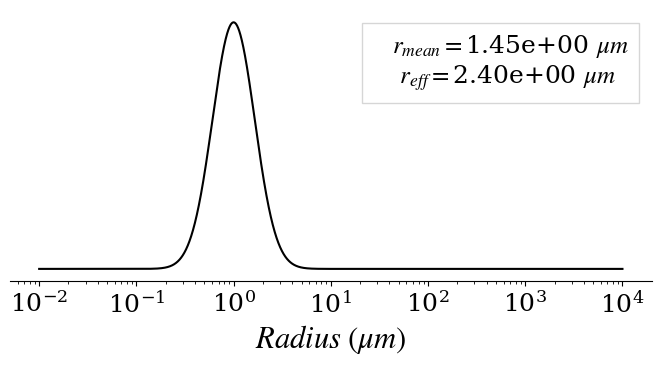

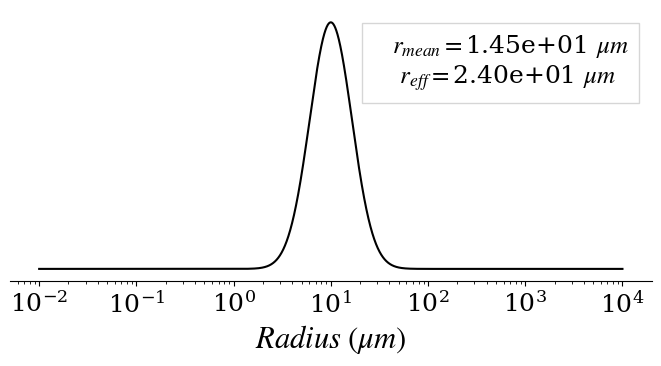

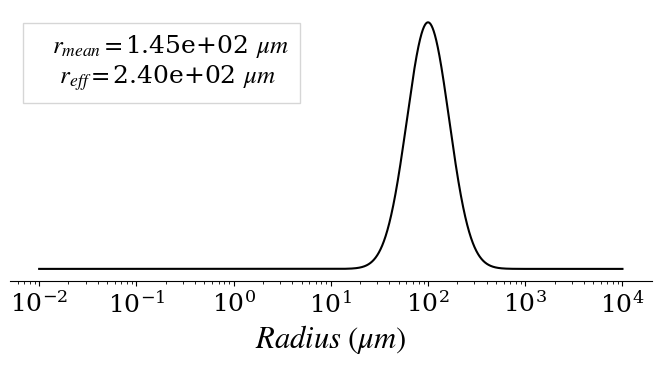

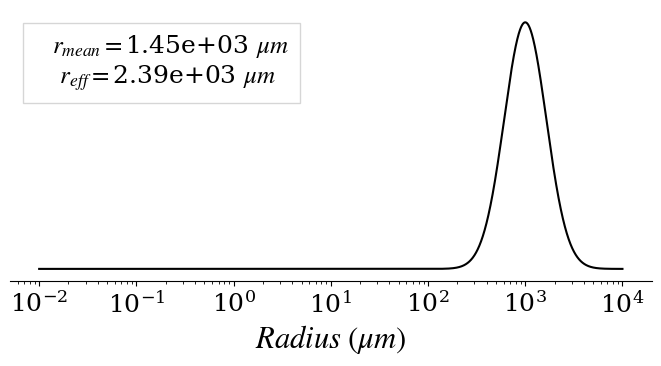

In [16]:
# -------------------------------------
# Load mueller matrix LUT
# of size parameters x = np.pi * diameter / wavelength (unitless)
# -------------------------------------
rootdir='/home/harmel/Dropbox/Dropbox/work/git/vrtc/mie_perso'
ofile = opj(rootdir,'mie_perso/data/mueller_mie_microplastic_v4.nc')
qfile = opj(rootdir,'mie_perso/data/Qeff_mie_microplastic_v4.nc')
mueller = xr.open_dataset(ofile)
xQeff = xr.open_dataset(qfile)

nMedium = 1.334
wl = 800
wl_medium = wl / nMedium
radius_super =  np.logspace(-2, np.log10(1e5), 5001)
# put into dask array
mueller = mueller.chunk(chunks={'nr': 1})
x = mueller.x
theta = mueller.theta
ang = theta * 180. / np.pi
Ntheta = len(mueller.theta)

radius_nm = x * wl_medium / (2 * np.pi)
radius_mic = 1e-3 * radius_nm
radius = radius_mic

# test size ditribution vs size parameter x
wavelengths_nm = np.arange(400,851,25)
rmed_list = [1., 10., 100., 1e3]
sigma = 0.5
#__________
# plot PSD
radius_super=np.logspace(-2,4,10000)
for i_rmed, rmed in enumerate(rmed_list):
    # compute size distribution
    ndp = psd.lognorm(radius_super, rn_med=rmed, sigma=sigma)* np.pi * radius_super
    plt.figure(figsize=(7, 4))
    handles = [mpl.patches.Rectangle((0, 0), 1, 1, fc="white", ec="white",
                                 lw=0, alpha=0)]
    ax = plt.subplot(111)
    ax.plot(radius_super, ndp,'k')

    # Hide the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_yaxis().set_ticks([])
    plt.semilogx()
    ax.set_xlabel('$Radius\ (\mu m)$')
    ax.minorticks_on()
    ax.legend(handles, [size_param(radius_super, ndp).to_annotation_r()], loc='best', fancybox=False,handlelength=0)
    plt.tight_layout()
    #plt.savefig('./mie_perso/fig/PSD_rmed'+str(rmed)+'.png',dpi=300)

In [ ]:
radius_super=np.logspace(-2,4,40000)
plt.figure(figsize=(8, 4))
handles = [mpl.patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", lw=0, alpha=0)]
ax = plt.subplot(111)
colors=['darkred','red','khaki','lightgray']
zorders=[6,5,4,3]
for i_rmed, rmed in enumerate(rmed_list):
    # compute size distribution
    ndp = psd.lognorm(radius_super, rn_med=rmed, sigma=sigma)* np.pi * radius_super

    ax.plot(radius_super, ndp,lw=4,color=colors[i_rmed],zorder=zorders[i_rmed])

    # Hide the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_yaxis().set_ticks([])
    plt.semilogx()
    ax.set_xlabel('$Radius\ (\mu m)$')
    ax.minorticks_on()
plt.tight_layout()
plt.savefig('./mie_perso/fig/all_PSD_detectability.png',dpi=300)

<xarray.Dataset> Size: 64B
Dimensions:   (r_med: 4)
Coordinates:
  * r_med     (r_med) float64 32B 1.0 10.0 100.0 1e+03
Data variables:
    vol_mean  (r_med) float64 32B 377.1 3.77e+05 3.566e+08 9.253e+10
Attributes:
    description:  Mean volume of a particle (micron**3)

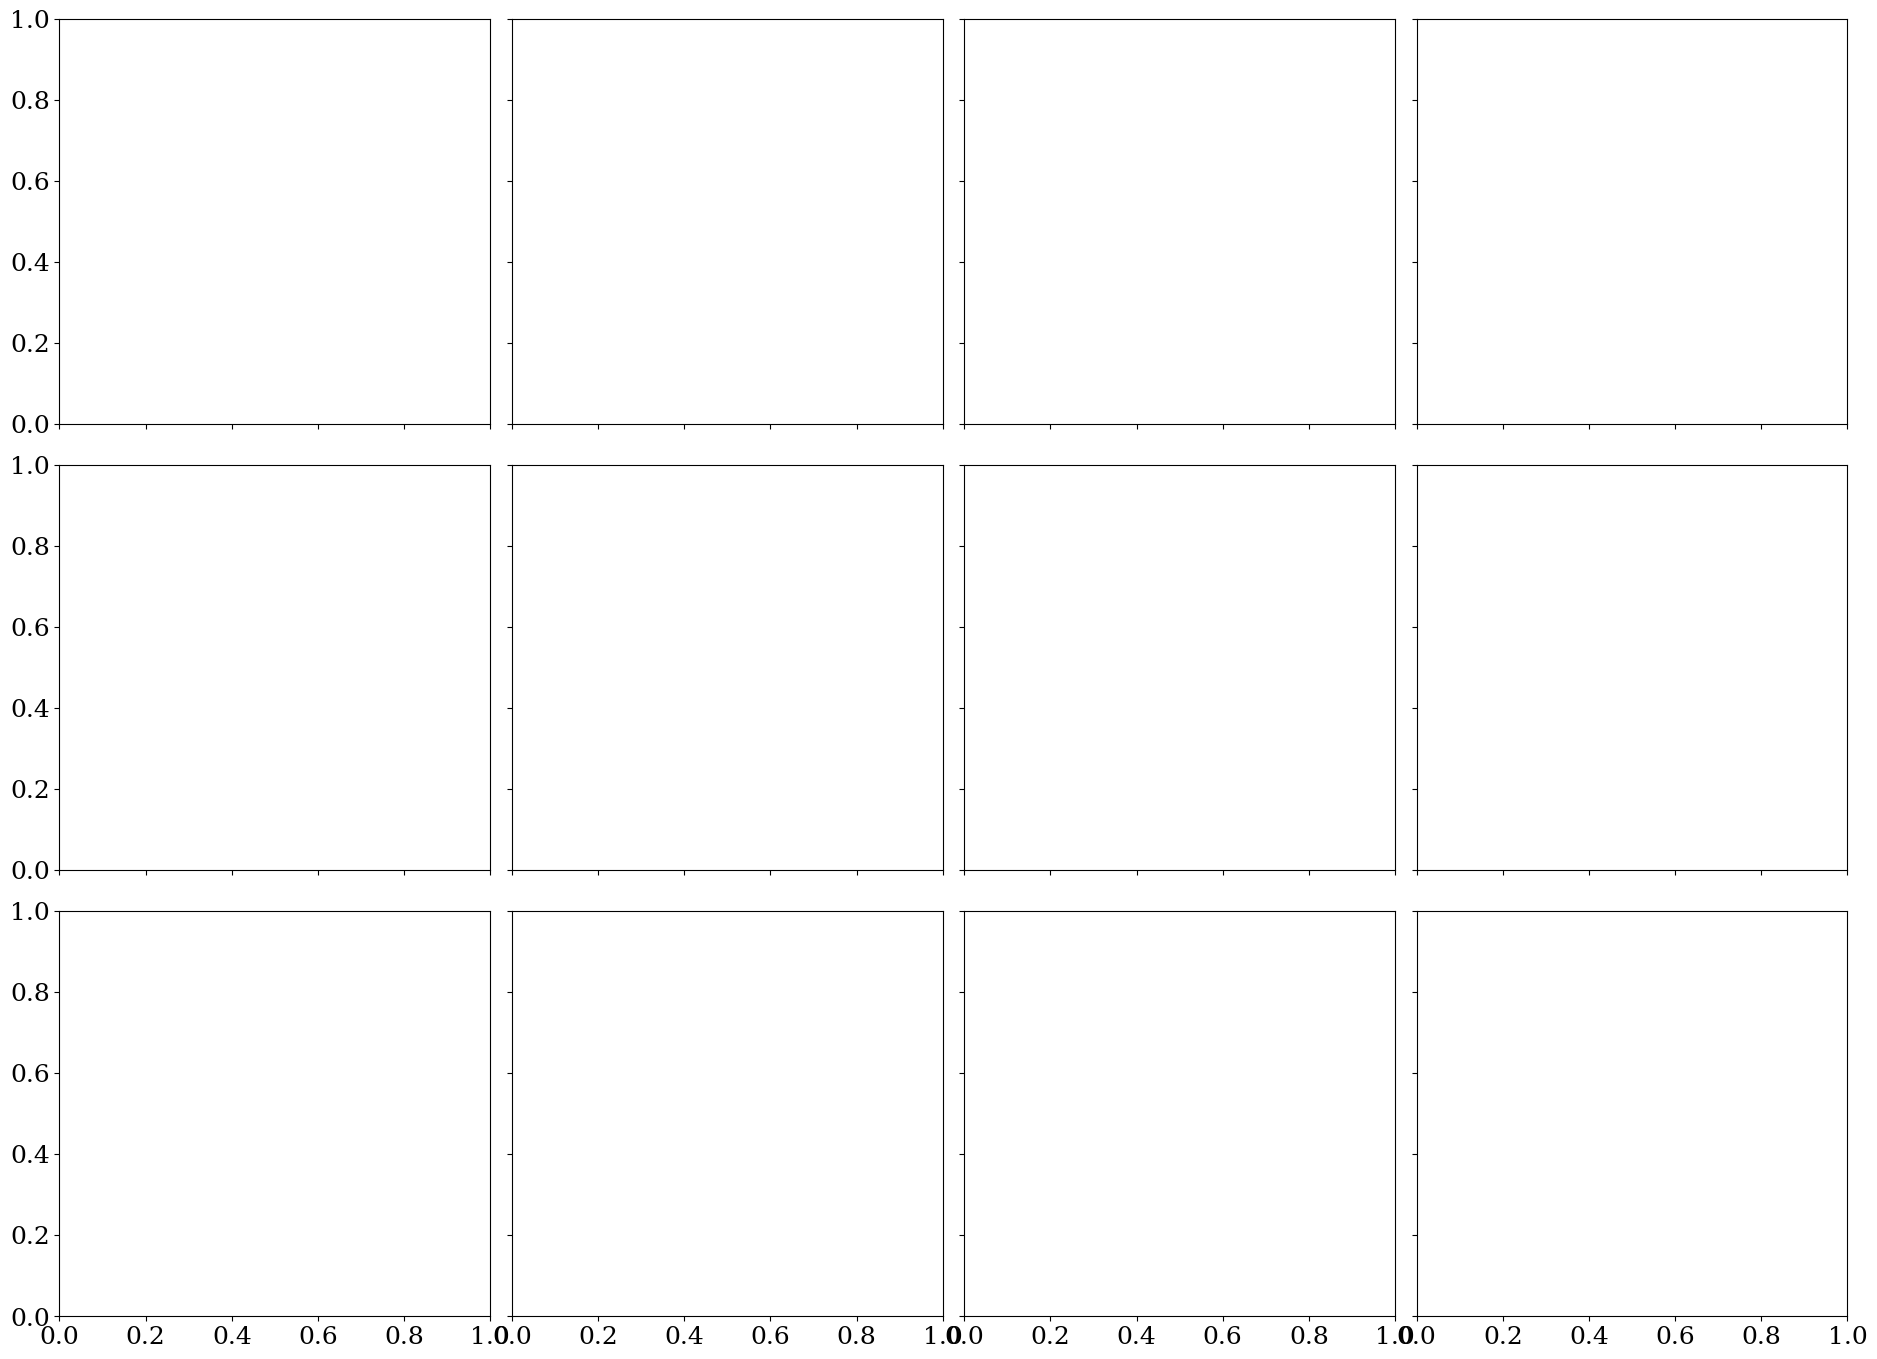

In [8]:
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', 'lightskyblue',
                                                     'orangered', "firebrick", "darkred",
                                                     'yellowgreen', 'forestgreen'])

fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(20, 15), sharex=True, sharey='row')
fig.subplots_adjust(bottom=0.115, top=0.98, left=0.086, right=0.98,
                    hspace=0.1, wspace=0.05)
norm = mpl.colors.LogNorm(vmin=1.05, vmax=1.2)
norm = mpl.colors.Normalize(vmin=1.01, vmax=1.21)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

lw = 1.2
alpha = 0.5
suff = ""
# suff='_full'
first = True

# compute mean volume of the particles in micron**-3


geom_=[]
radius =radius_super
for i_rmed, rmed in enumerate(rmed_list):
    # compute size distribution
    ndp = psd.lognorm(radius, rn_med=rmed, sigma=sigma)

    # compute mean volume of the particles in micron**-3
    ndp_norm = np.trapz(ndp, radius)
    vol_mean = np.trapz(ndp * 4 / 3 * np.pi * radius ** 3, radius) / ndp_norm
    geom_.append([rmed,vol_mean])
geom = pd.DataFrame(geom_,columns=['r_med','vol_mean']).set_index(['r_med']).to_xarray().assign_attrs({'description':'Mean volume of a particle (micron**3)'})
geom

In [18]:
scat_mat = []
CrossSection = []

for wavelength in wavelengths_nm:
    wavelength_medium = wavelength / nMedium
    radius_nm = mueller.x * wavelength_medium / np.pi / 2
    radius_mic = 1e-3 * radius_nm
    radius = radius_mic

    scat_mat_ = []
    CrossSection_ = []
    for i_rmed, rmed in enumerate(rmed_list):
        # compute size distribution
        ndp = psd.lognorm(radius, rn_med=rmed, sigma=sigma)

        # compute mean volume of the particles in micron**-3
        ndp_norm = np.trapz(ndp, radius)

        # integrate mueller matrix with size distribution (convert wavelength in micron)
        mueller_ = (wavelength_medium * 1e-3) ** 2 / np.pi * mueller.assign_coords(
            radius=("x", radius.data)) * ndp
        mueller_int = mueller_.integrate('radius').compute()/ndp_norm
        scat_mat_.append(mueller_int.assign_coords({'r_med': rmed, 'wavelength': wavelength}))

        # compute cross section for size distribution in micron**2
        Csca_ = xQeff.Qsca.isel(ni=0).assign_coords(radius=("x", radius.data)) * (
                np.pi * radius.data ** 2 * ndp)
        Cext_ = xQeff.Qext.isel(ni=0).assign_coords(radius=("x", radius.data)) * (
                np.pi * radius.data ** 2 * ndp)
        Csca_int = Csca_.integrate('radius').compute().assign_coords({'r_med': rmed, 'wavelength': wavelength})/ndp_norm
        Cext_int = Cext_.integrate('radius').compute().assign_coords({'r_med': rmed, 'wavelength': wavelength})/ndp_norm
        CrossSection_.append(xr.Dataset({'Csca': Csca_int, 'Cext': Cext_int}))

    # concatenate xarray on the r_med dimension
    scat_mat.append(xr.concat(scat_mat_, dim='r_med'))
    CrossSection.append(xr.concat(CrossSection_, dim='r_med'))

# concatenate xarray on the wavelength dimension
xCrossSection = xr.concat(CrossSection, dim='wavelength')
xscat_mat = xr.concat(scat_mat, dim='wavelength')
# TODO save into netcdf with good file naming

In [19]:
xCrossSection

<xarray.Dataset> Size: 54kB
Dimensions:     (wavelength: 19, r_med: 4, nr: 44)
Coordinates:
  * nr          (nr) float64 352B 1.005 1.01 1.015 1.02 ... 1.21 1.215 1.22
    ni          float64 8B 0.0
  * r_med       (r_med) float64 32B 1.0 10.0 100.0 1e+03
  * wavelength  (wavelength) int64 152B 400 425 450 475 500 ... 775 800 825 850
Data variables:
    Csca        (wavelength, r_med, nr) float64 27kB 0.4965 1.84 ... 1.003e+07
    Cext        (wavelength, r_med, nr) float64 27kB 0.4965 1.84 ... 1.003e+07

<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:50: SyntaxWarning: invalid escape sequence '\ '
<>:87: SyntaxWarning: invalid escape sequence '\ '
<>:87: SyntaxWarning: invalid escape sequence '\ '
<>:94: SyntaxWarning: invalid escape sequence '\ '
<>:101: SyntaxWarning: invalid escape sequence '\ '
<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:50: SyntaxWarning: invalid escape sequence '\ '
<>:87: SyntaxWarning: invalid escape sequence '\ '
<>:87: SyntaxWarning: invalid escape sequence '\ '
<>:94: SyntaxWarning: invalid escape sequence '\ '
<>:101: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_722897/3615426293.py:23: SyntaxWarning: invalid escape sequence '\ '
  ax.set_xlabel('$Refractive\ index$')
/tmp/ipykernel_722897/3615426293.py:50: SyntaxWarning: invalid escape sequence '\ '
  axs[i].set_xlabel('$Scattering\ angle\ (deg)$')
/tmp/ipykernel_722897/3615426293.py:87: SyntaxWarning: invalid escape sequence '\ '
  axs[0, i_rmed].set_title('$Lognorm,\ r_m = 

0.03156883555245976 0.03156883555245976 0.03156777169876625
0.002807827524174437 0.002807827524174437 0.002798870882413996
0.00029182804598748677 0.00029182804598748677 0.00021436957345583605
7.644866587350924e-05 7.644866587350924e-05 4.016622972086007e-05
0.031859802584166146 0.031859802584166146 0.03185884630354844
0.0028104559298613397 0.0028104559298613397 0.002802521215190108
0.0002918831015261544 0.0002918831015261544 0.00021920537081937413
8.03682793820401e-05 8.03682793820401e-05 4.228956351038503e-05
0.03214880342416875 0.03214880342416875 0.032147937541484276
0.0028130446635162183 0.0028130446635162183 0.002805964892387951
0.00029193687858299126 0.00029193687858299126 0.00022384442187909202
8.392443457511127e-05 8.392443457511127e-05 4.422988066544134e-05
0.0324326743315093 0.0324326743315093 0.03243188517104614
0.0028155967007118597 0.0028155967007118597 0.0028092395565494106
0.00029198949114810085 0.00029198949114810085 0.00022826255910645966
8.713315364485832e-05 8.713315

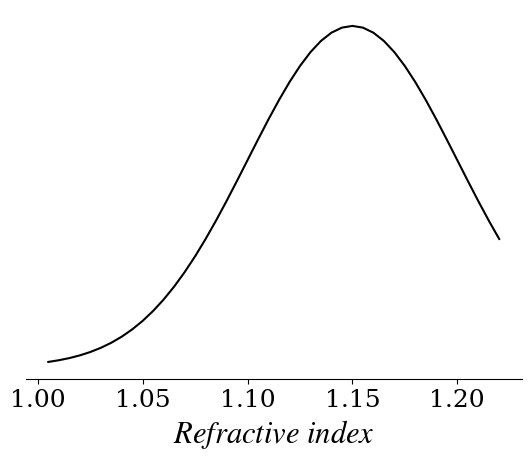

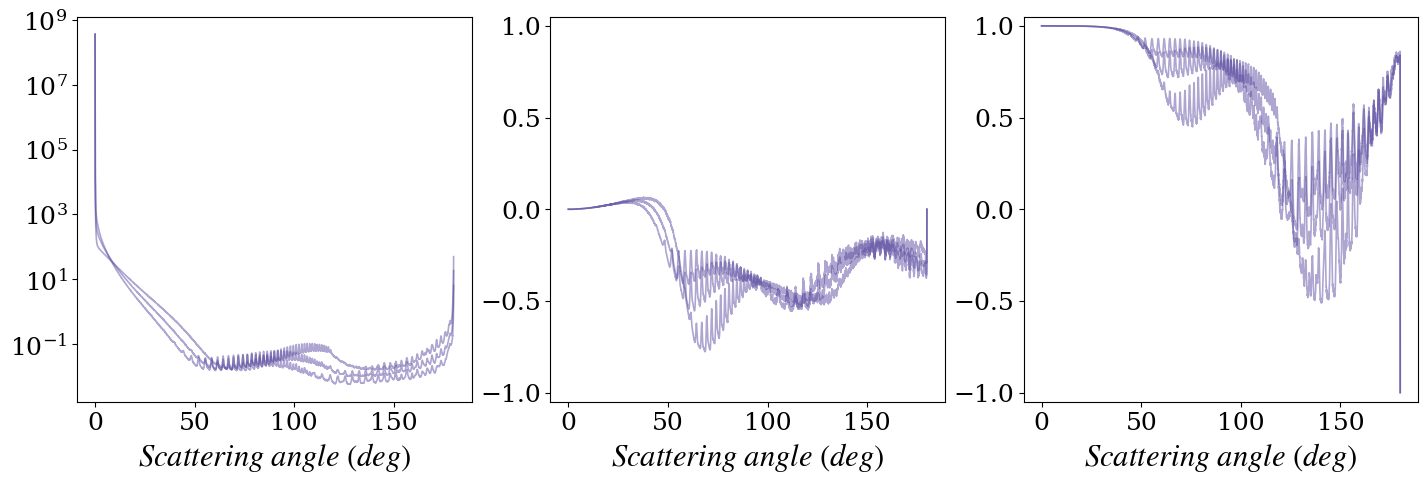

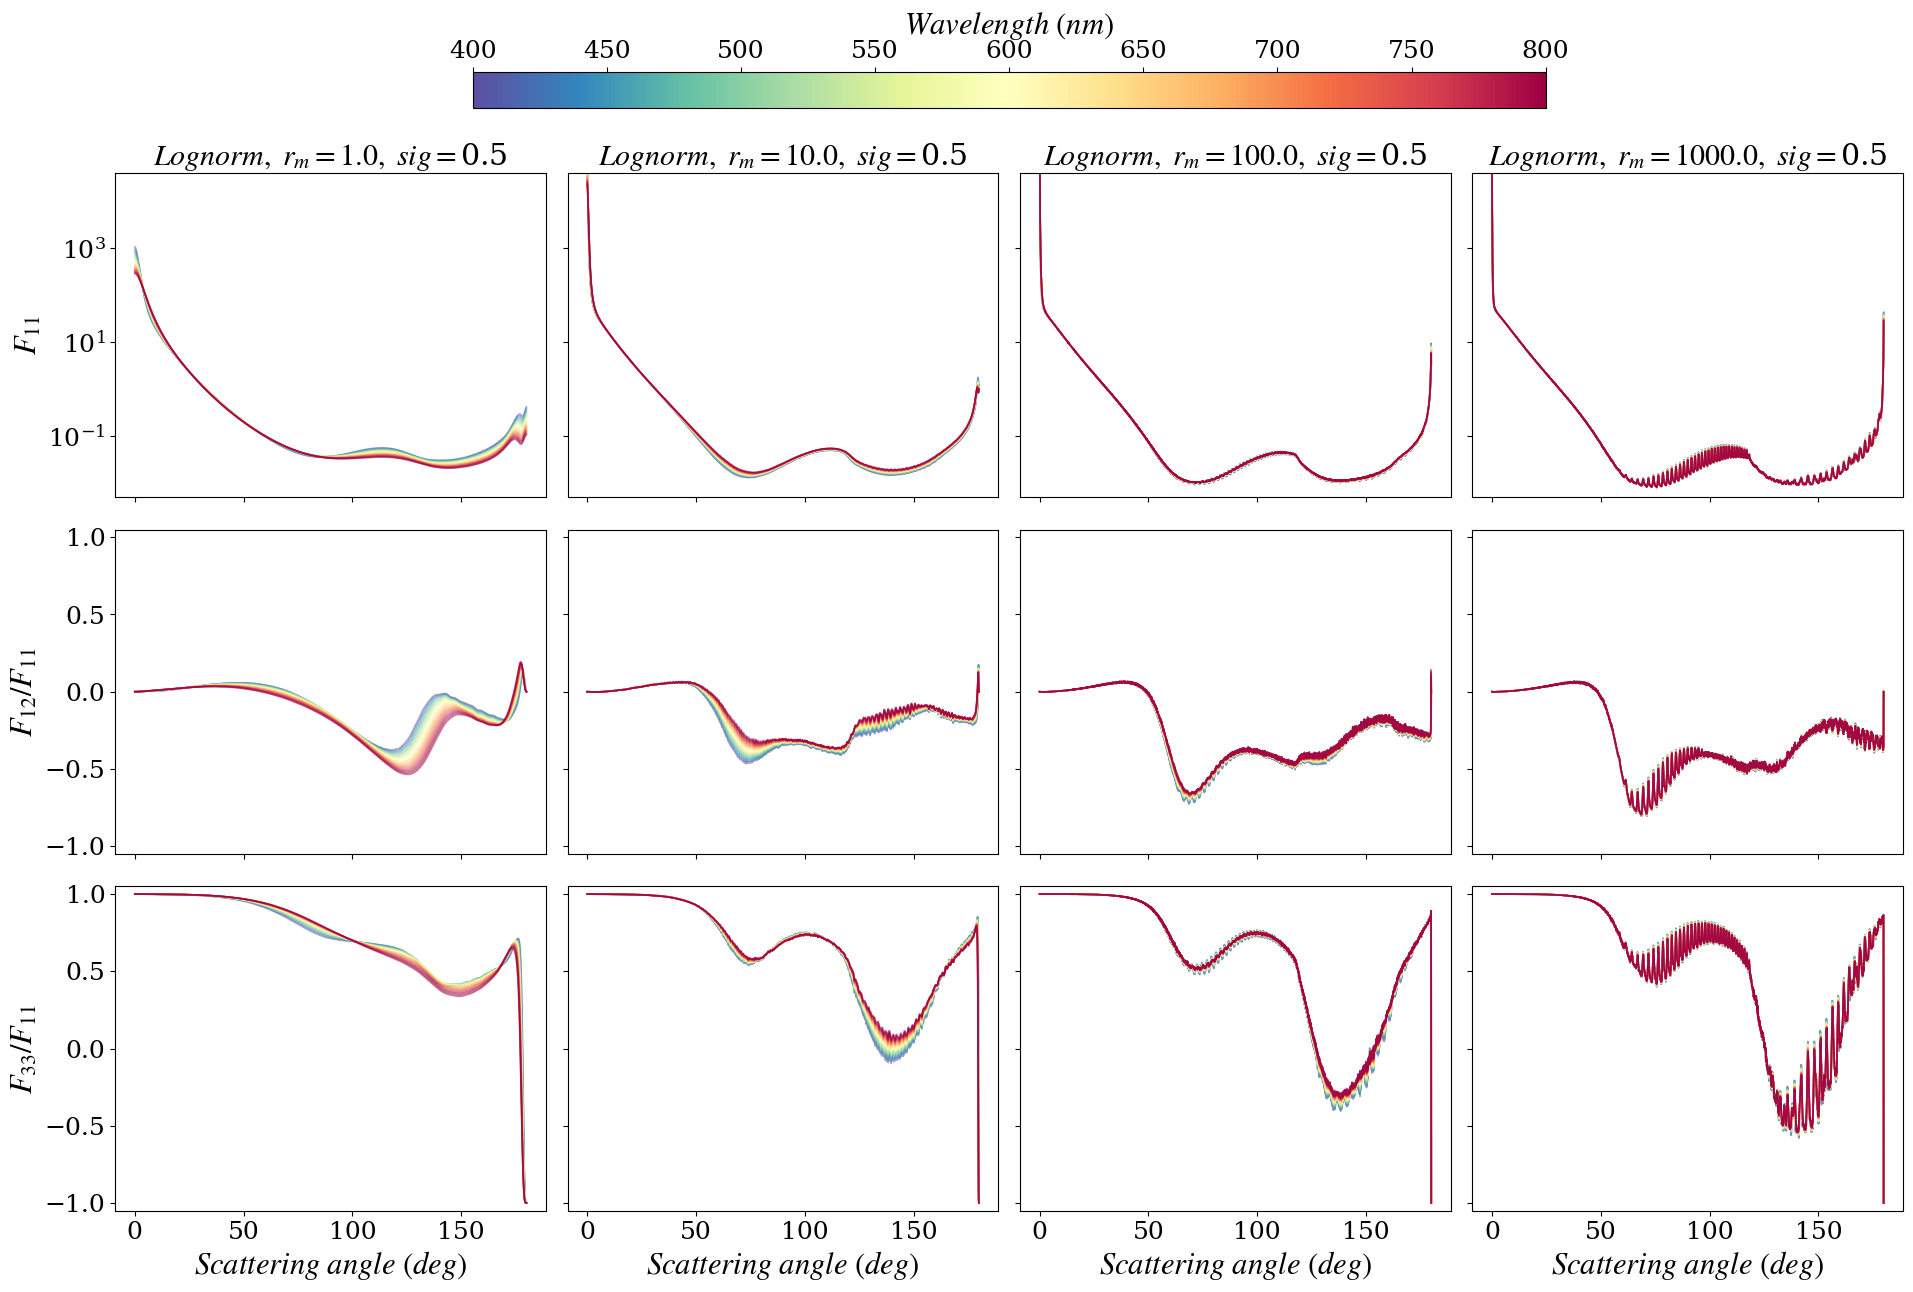

In [22]:
# -------------------------------------
# Integrate over refractive index distribution
#
# -------------------------------------

nr = xscat_mat.nr

# nr = np.linspace(1.05,1.2,100)
# nr=xr.DataArray(nr,coords=dict(nr=nr))
# mueller_int = mueller_int.interp(nr=nr)
nr_=1.15
nr_dist = psd.norm(nr, nr_, 0.05)
(xscat_mat * nr_dist).integrate('nr')

ax = plt.subplot(111)
ax.plot(nr, nr_dist,'k')

# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_ticks([])
ax.set_xlabel('$Refractive\ index$')

#plt.savefig('./mie_perso/fig/refrac_index_distrib.png',dpi=300)
np.trapz(nr_dist, nr)
sigma = 0.5
lw = 1.2
alpha = 0.5

xscat_mat_ = xscat_mat.sel(wavelength=800,r_med=1000)
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharex=True)
fig.subplots_adjust(bottom=0.15, top=0.92, left=0.086, right=0.98,
                    hspace=0.1, wspace=0.2)
for nr_ in [1.05, 1.09, 1.145]:
    nr_dist = psd.norm(nr, nr_, 0.05)
    mueller_super = (xscat_mat_ * nr_dist).integrate('nr')
    S11 = mueller_super.S11
    Cscat = np.trapz(S11 * np.sin(theta), theta) / 2
    S12 = mueller_super.S12 / S11
    S33 = mueller_super.S33 / S11
    axs[0].plot(ang, S11 / Cscat, color=cmap(norm(nr_)), lw=lw, alpha=alpha)
    axs[1].plot(ang, S12, color=cmap(norm(nr_)), lw=lw, alpha=alpha)
    axs[2].plot(ang, S33, color=cmap(norm(nr_)), lw=lw, alpha=alpha)
axs[1].set_ylim([-1.05, 1.05])
axs[2].set_ylim([-1.05, 1.05])
axs[0].semilogy()

for i in range(3):
    axs[i].set_xlabel('$Scattering\ angle\ (deg)$')



cmap = plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=400, vmax=800)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(20, 15), sharex=True, sharey='row')
fig.subplots_adjust(bottom=0.115, top=0.98, left=0.086, right=0.98,
                    hspace=0.1, wspace=0.05)

nr_=1.15
first=True
for wavelength in xscat_mat.wavelength.data:
    for i_rmed, rmed in enumerate(xscat_mat.r_med.data):
        xscat_mat_ = xscat_mat.sel(r_med=rmed,wavelength=wavelength)
        vol_mean = geom.vol_mean.sel(r_med=rmed).data
        nr_dist = psd.norm(nr, nr_, 0.05)
        nr_dist_norm = np.trapz(nr_dist,nr)

        mueller_super = (xscat_mat_ * nr_dist).integrate('nr')/nr_dist_norm

        Cross = xCrossSection.sel(r_med=rmed,wavelength=wavelength)
        Csca = (Cross.Csca* nr_dist).integrate('nr')/nr_dist_norm
        Cext = (Cross.Cext* nr_dist).integrate('nr')/nr_dist_norm

        S11 = mueller_super.S11
        Cscat = np.trapz(S11 * np.sin(theta), theta) / 2
        print(Cext.values/vol_mean,Csca.values/vol_mean,Cscat/vol_mean)

        S12 = mueller_super.S12 / S11
        S33 = mueller_super.S33 / S11
        axs[0, i_rmed].plot(ang, S11 / Csca, color=cmap(norm(wavelength)), lw=lw, alpha=alpha)
        axs[1, i_rmed].plot(ang, S12, color=cmap(norm(wavelength)), lw=lw, alpha=alpha)
        axs[2, i_rmed].plot(ang, S33, color=cmap(norm(wavelength)), lw=lw, alpha=alpha)
        if first:
            axs[0, i_rmed].set_title('$Lognorm,\ r_m = ' + str(rmed) + ',\ sig=$' + str(sigma))

    first = False
axs[1,0].set_ylim([-1.05, 1.05])
axs[2,0].set_ylim([-1.05, 1.05])
axs[0,0].semilogy()
for i in range(4):
    axs[-1, i].set_xlabel('$Scattering\ angle\ (deg)$')
axs[0, 0].set_ylim([5e-3, 4e4])
# axs[0, 0].legend()
axs[0, 0].set_ylabel('$F_{11}$')
axs[1, 0].set_ylabel('$F_{12}/F_{11}$')
axs[2, 0].set_ylabel('$F_{33}/F_{11}$')
cb = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=30, pad=0.05, location='top', format=mpl.ticker.ScalarFormatter())
cb.set_label('$Wavelength\ (nm)$', fontsize=22)

plt.savefig('../mie_perso/fig/scat_mat_psd_lognorm_osoaa'+str(nr_)+'.png', dpi=300)

In [ ]:
# ----------------------------------------
# Generate OSOAA scat mat file
nr_=1.15
first=True
for wavelength in xscat_mat.wavelength.data:
    for i_rmed, rmed in enumerate(xscat_mat.r_med.data):

        ofile = './mie_perso/lut/scat_mat_psd_lognorm_osoaa_nr'+str(nr_)+'_rmed'+str(rmed)+'_wl'+str(wavelength)+'.csv'

        xscat_mat_ = xscat_mat.sel(r_med=rmed,wavelength=wavelength)
        vol_mean = geom.vol_mean.sel(r_med=rmed).data
        nr_dist = psd.norm(nr, nr_, 0.05)
        nr_dist_norm = np.trapz(nr_dist,nr)

        mueller_super = (xscat_mat_ * nr_dist).integrate('nr')/nr_dist_norm

        Cross = xCrossSection.sel(r_med=rmed,wavelength=wavelength)
        Csca = (Cross.Csca* nr_dist).integrate('nr')/nr_dist_norm
        Cext = (Cross.Cext* nr_dist).integrate('nr')/nr_dist_norm

        S11 = mueller_super.S11
        Cscat = np.trapz(S11 * np.sin(theta), theta) / 2
        print(Cext.values/vol_mean,Csca.values/vol_mean,Cscat/vol_mean)

        S12 = mueller_super.S12 / S11
        S33 = mueller_super.S33 / S11
        S11 = S11 / Cscat
        # set S22 to one
        S22=S11*0+1
        mat = xr.Dataset({'s11':S11,'s12':S12,'s22':S22,'s33':S33})
        mat = mat.assign_coords(theta=np.degrees(mat.theta))
        df_mat = mat.reset_coords(drop=True).to_pandas()
        Nang = len(mueller_super.theta)

        Cext_ = "{:12.6e}".format(Cext.values)
        Csca_ = "{:12.6e}".format(Csca.values)
        V_mean_ = "{:12.6e}".format(vol_mean)
        # check normalization:
        theta_rad = np.deg2rad(df_mat.index)
        print(np.trapz(df_mat.s11 * np.sin(theta_rad), theta_rad))


        header = 'Cext : '+Cext_+'\nCsca : '+Csca_+'\nvol_mean : '+V_mean_+\
                 '\nNb angles : '+str(Nang)+'\n'

        with open(ofile, 'w') as fp:
            fp.write(header)
        df_mat.to_csv(ofile,sep=' ', header=True, mode='a')